# Задача предсказания согласия клиента на депозит 

**Цель:** провести исследование данных о клиентах банка и маркетинговых кампаниях, сформулировать задачу бинарной классификации, выбрать метрику качества и выполнить EDA

**Бизнес-постановка:**
банк проводит телефонные кампании, предлагая клиентам открыть срочный депозит. Необходимо спрогнозировать, согласится ли клиент на предложение.  
Предсказание позволит банку оптимизировать маркетинговые затраты

**ML-постановка:**
задача бинарной классификации: по социально-демографическим и поведенческим признакам клиента определить вероятность положительного отклика (`y = 1` - открыл депозит, `y = 0` - отказался)

In [38]:
# Воспроизводимость
RANDOM_STATE = 42

# Основное
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

seed = 42
np.random.seed(seed)


In [5]:
# Фиксируем настройки отображения графиков
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# 1 Обзор датасета

Датасет содержит сведения о клиентах банка, параметрах их предыдущих контактов и макроэкономических условиях.  
целевая переменная `y` - отклик клиента на предложение оформить депозит (`yes` / `no`).

| категория признаков | название | описание |
|----------------------|-----------|-----------|
| **Социально-демографические** | age | возраст клиента (числовой) |
|  | job | тип занятости (admin., services, technician и др.) |
|  | marital | семейное положение (single, married, divorced) |
|  | education | уровень образования |
|  | default | есть ли дефолт по кредиту |
|  | housing | наличие ипотечного кредита |
|  | loan | наличие персонального кредита |
| **Текущая кампания** | contact | тип связи (cellular, telephone) |
|  | month | месяц последнего контакта |
|  | day_of_week | день недели последнего контакта |
|  | duration | длительность последнего звонка (сек) |
|  | campaign | число контактов в текущей кампании |
| **Предыдущие кампании** | pdays | дни с момента последнего контакта (999 = не контактировали) |
|  | previous | число контактов до текущей кампании |
|  | poutcome | исход предыдущей кампании (failure, success, nonexistent) |
| **Макроэкономические индикаторы** | emp.var.rate | квартальный показатель изменения занятости |
|  | cons.price.idx | индекс потребительских цен |
|  | cons.conf.idx | индекс доверия потребителей |
|  | euribor3m | ставка межбанковского кредитования (3 мес) |
|  | nr.employed | количество занятых (в тыс.) |
| **Целевая переменная** | y | отклик клиента на предложение депозита (`yes` / `no`) |


In [12]:
data_path = "/kaggle/input/bank-additional/bank-additional-full.csv"
df = pd.read_csv(data_path, sep=";", na_values="unknown", low_memory=False)

print("shape:", df.shape)
display(df.head(5))


shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
print("\ninfo():")
df.info()


info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   marital         41108 non-null  object 
 3   education       39457 non-null  object 
 4   default         32591 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 

In [11]:
print("\nclass balance for y:")
print(df["y"].value_counts(normalize=True))


class balance for y:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


## Обзор датасета

Содержит 41 188 наблюдений и 21 признак 

Часть признаков - числовые (`age`, `duration`, `campaign`, `pdays`, `previous`),  
Остальные - категориальные (`job`, `marital`, `education`, `contact`, `month`, `day_of_week`,  ...)

Есть единичные пропуски, например в признаке `default` - они будут найдены и обработаны далее на этапе предобработки

Целевая переменная y имеет сильный дисбаланс:  
Около 88,7 % клиентов отказались (no) и только 11,3 % согласились (yes) внести депозит


# 2 Пропуски

In [14]:
# f для отчета по пропускам: сколько и какая доля от дdf
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    s = df.isna().sum()
    s = s[s > 0].sort_values(ascending=False)
    return s.to_frame("n_missing").assign(frac=lambda x: x["n_missing"] / len(df))

In [17]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("num cols:", num_cols)
print("cat cols:", [c for c in cat_cols if c != "y"])

num cols: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
cat cols: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [18]:
miss = missing_report(df)
display(miss.head(20))

,n_missing,frac
default,8597,0.208726
education,1731,0.042027
housing,990,0.024036
loan,990,0.024036
job,330,0.008012
marital,80,0.001942


## Числовые и категориальные признаки, пропуски

Всего 8 числовых и 12 категориальных признаков  

Пропуски встречаются только в нескольких категориальных столбцах:
- default 20 % 
- education 4 %
- housing и loan по 2,4 %
- job 0.8 %
- material менее 0.2 %

# 3 Базовые статистики и баланс классов (график)

In [21]:
# базовые статистики только для числовых колонок
display(df[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


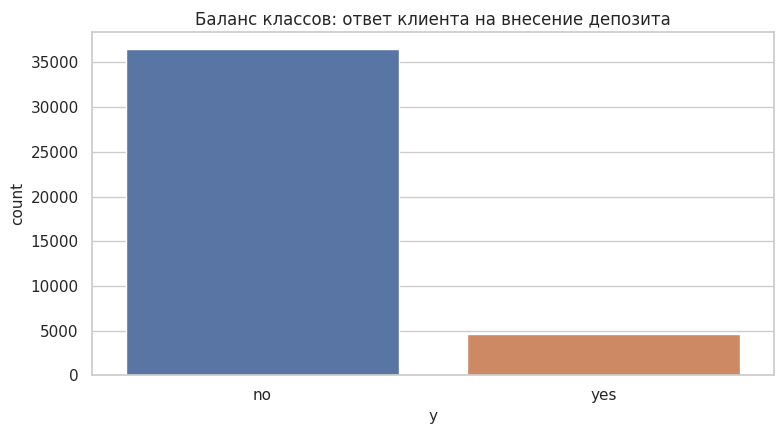

In [25]:
# Баланс классов
sns.countplot(x="y", data=df)
plt.title("Баланс классов: ответ клиента на внесение депозита")
plt.xlabel("y")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Базовые статистики 

Средний возраст клиентов составляет около 40 лет , диапазон — от 17 до 98 лет

Продолжительность последнего звонка (`duration`) сильно варьируется: медиана 180 сек, но встречаются звонки до 4900 сек — возможные выбросы

Число контактов в текущей кампании (`campaign`) в среднем около 2-3, но есть клиенты с более чем 50 звонками

Переменная `pdays` имеет характерный пик на 999 - "клиент не контактировал ранее" (не пропуск, а условное значение)  

## Баланс классов

График баланса классов показывает выраженный дисбаланс: около 89 % отказов (no) и только 11 % согласий (yes)  
При последующем обучении важно будет использовать подходящие метрики и техники балансировки, чтобы модель не смещалась в сторону большинства


# 4 Распределения (графики)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


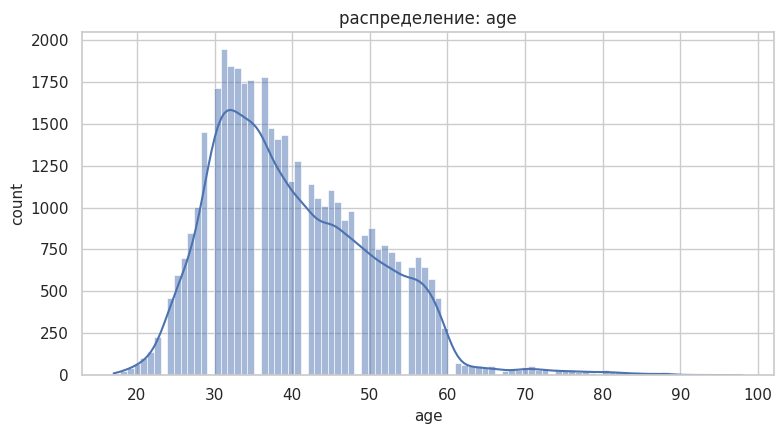

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


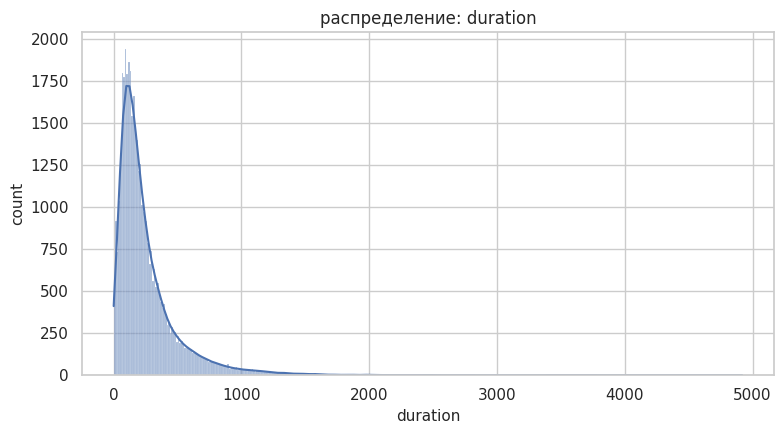

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


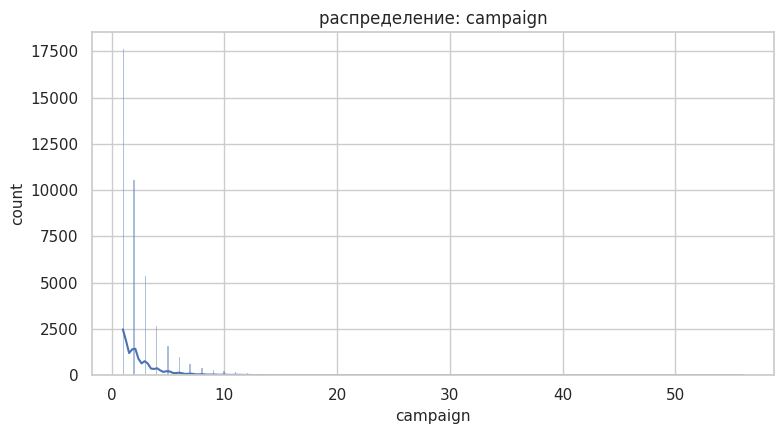

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


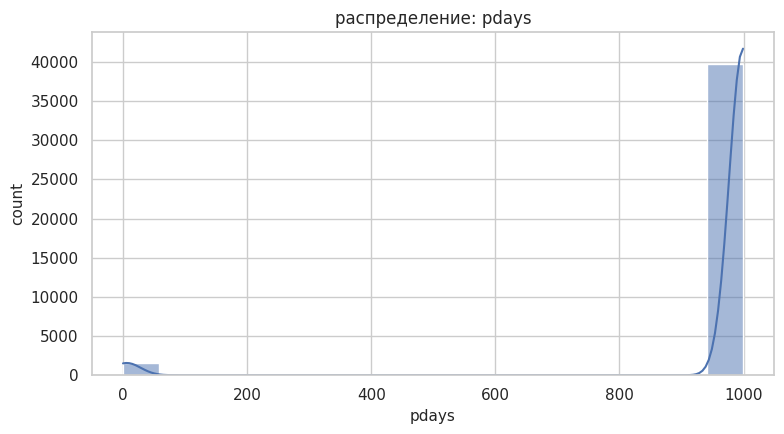

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


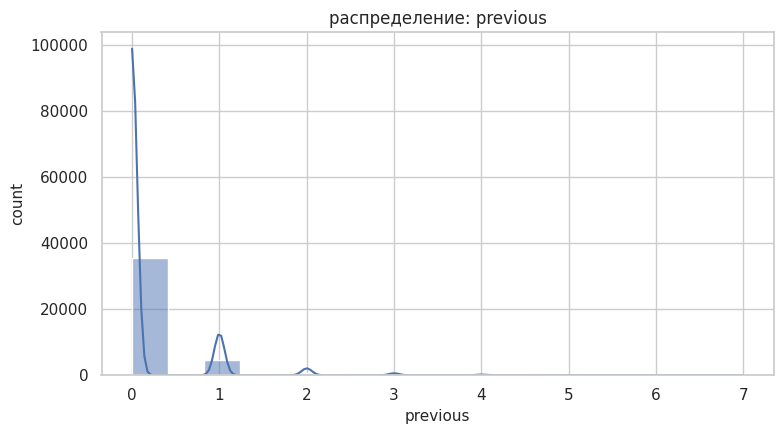

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


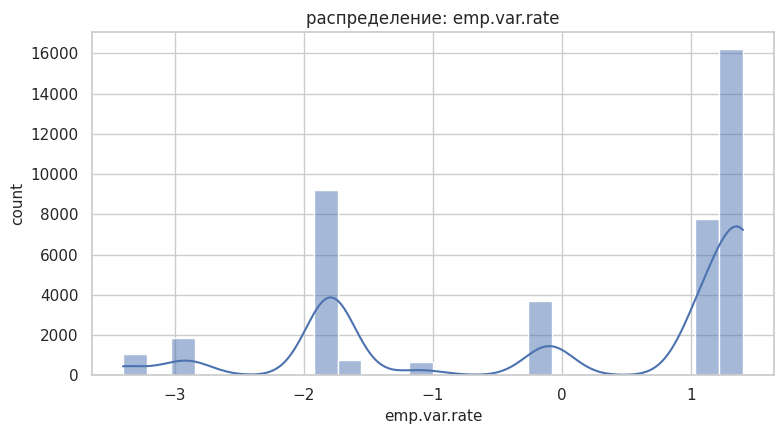

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


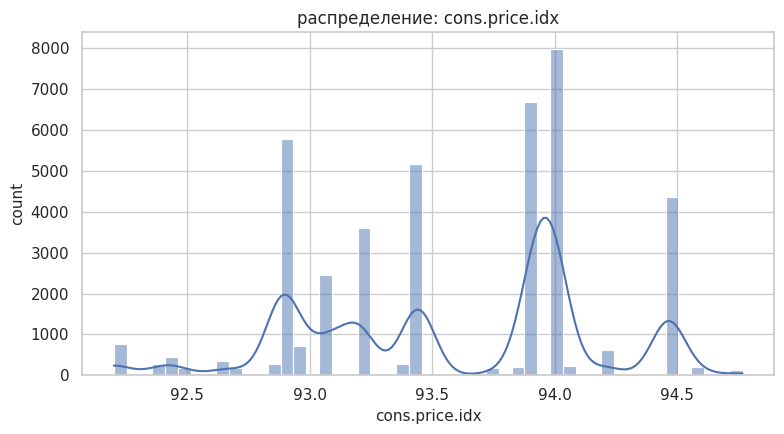

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


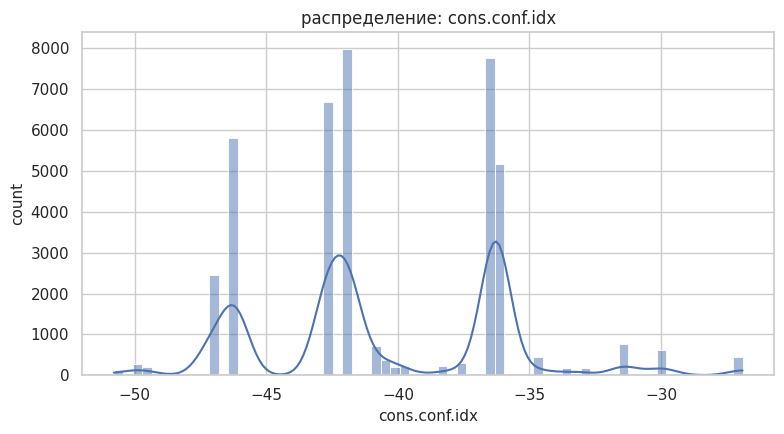

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


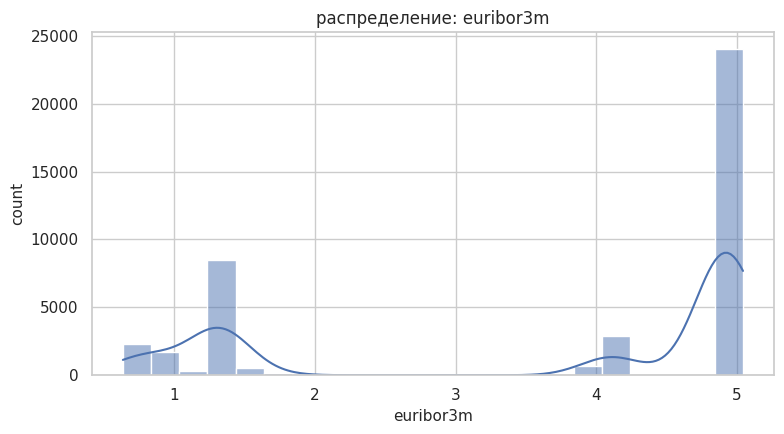

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


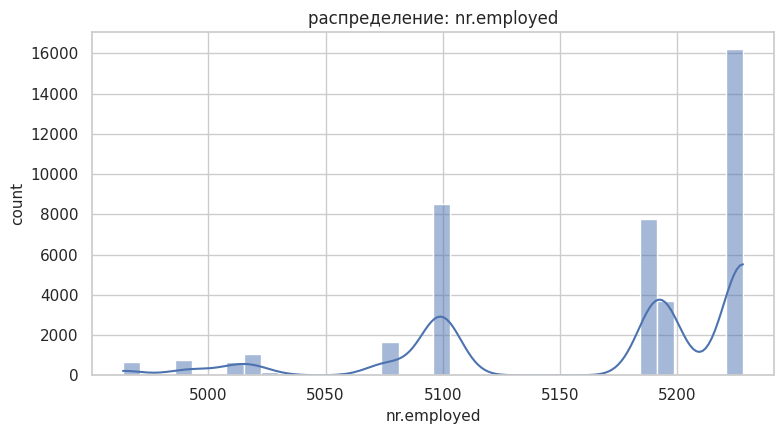

In [27]:
for col in num_cols:
    fig, ax = plt.subplots()
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set(title=f"распределение: {col}", xlabel=col, ylabel="count")
    plt.tight_layout(); plt.show()

## Распределения числовых признаков: наблюдения

- **age** - распределение с правым хвостом (пик 30–40 лет, есть клиенты 60+). Выбросы небольшие.
- **duration** - смещено вправо: большинство звонков до 5 минут, есть редкие очень длинные (до 4900 сек) 
  > важное: `duration` известен только после звонка; использовать эту фичу в обучении = риск утечки, из моделей исключим
- **campaign** - правый хвост, медиана 2-3 контакта, редкие значения >10 выглядят как выбросы. Для модели можно рассмотреть обрезку по 99-му перцентилю или лог-преобразование
- **pdays** - почти все значения 999 (код «раньше не контактировали»), небольшой кластер малых значений
  Возможно, стоит создать бинарную фичу `prev_contacted = (pdays != 999)` и сам `pdays` трактовать отдельно (или заменить 999 на nan)
- **previous** - большинство клиентов не контактировали ранее, единичные значения 1–3+

Общая картина: много распределений, смещённых вправо, а также «технических» кодов (pdays=999). Для корректного обучения потребуется:
1) обработать спец-значения (`pdays`)
2) исключить из моделей `duration` (во избежание утечек)  
3) Стабилизировать хвосты (лог-преобразование/обрезка)

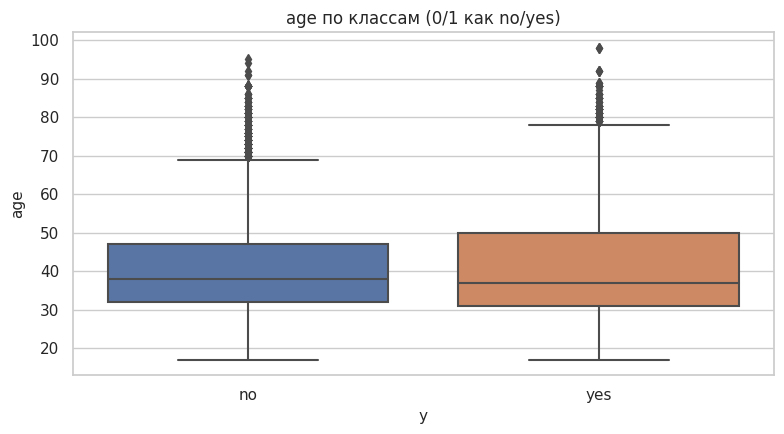

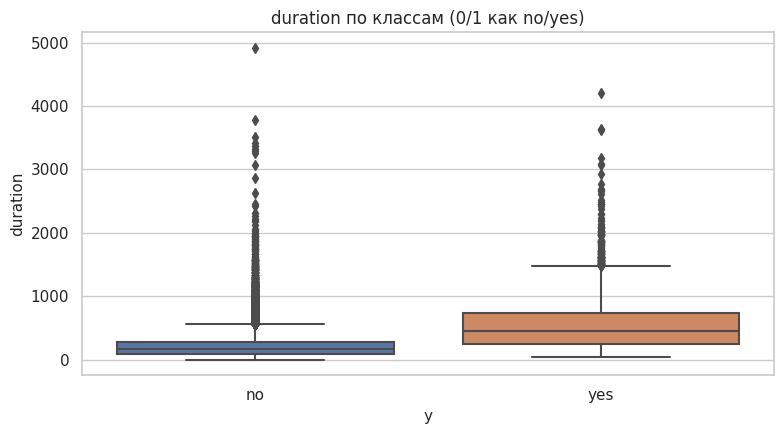

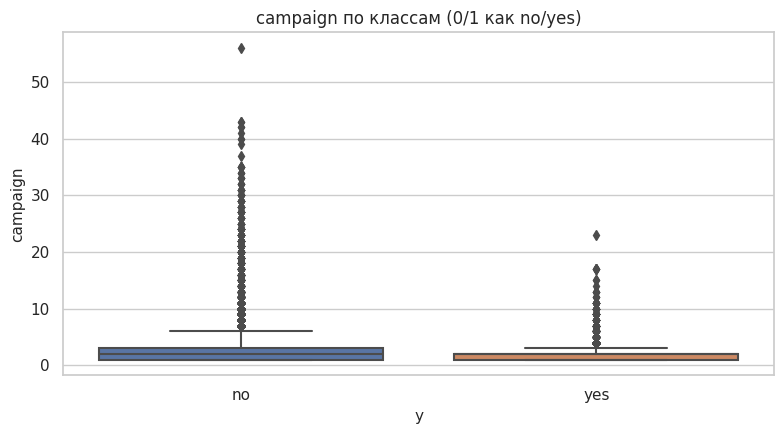

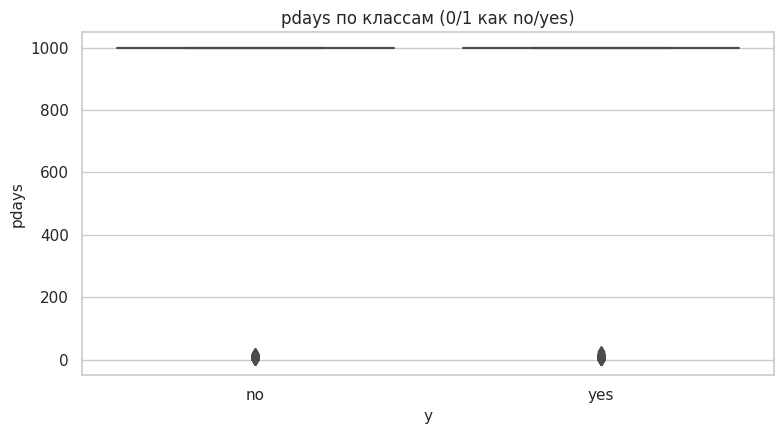

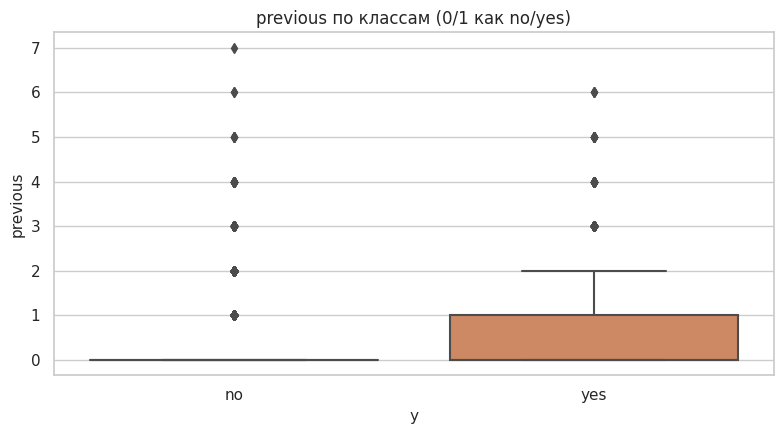

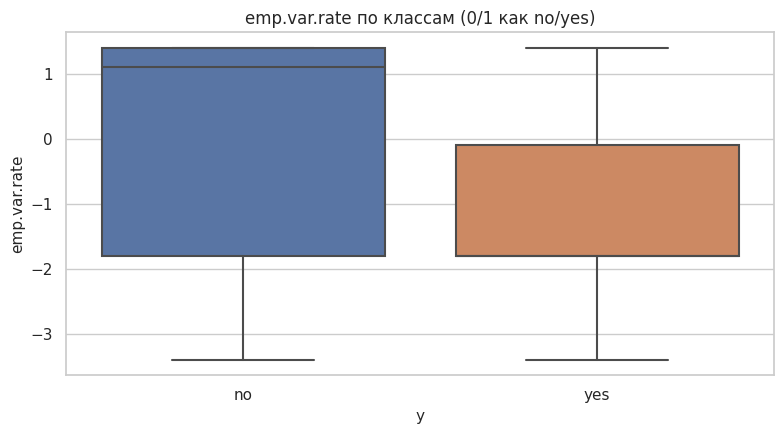

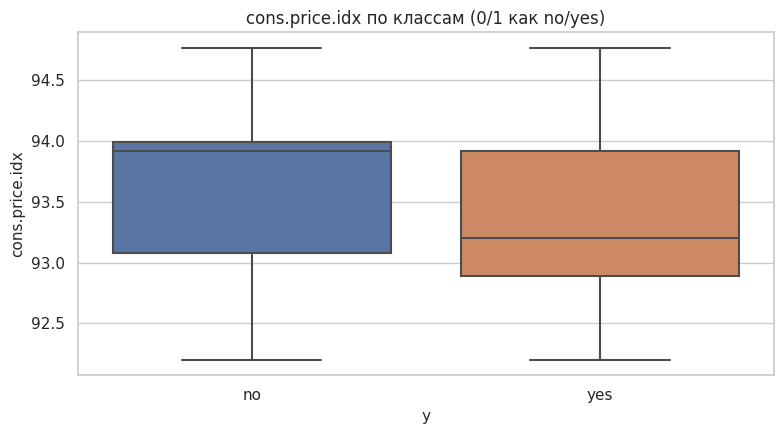

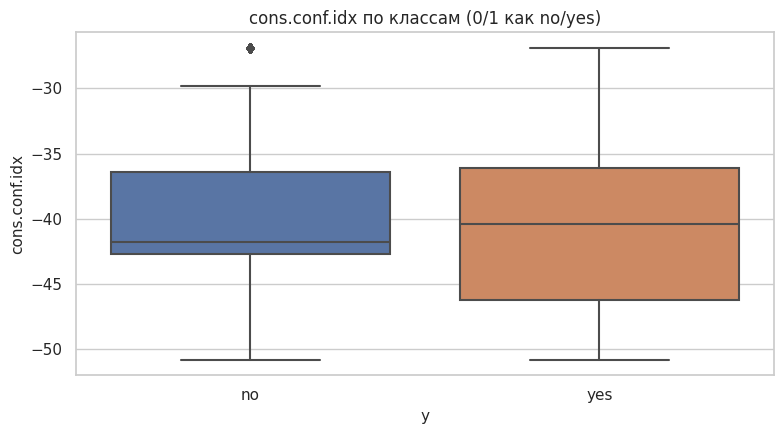

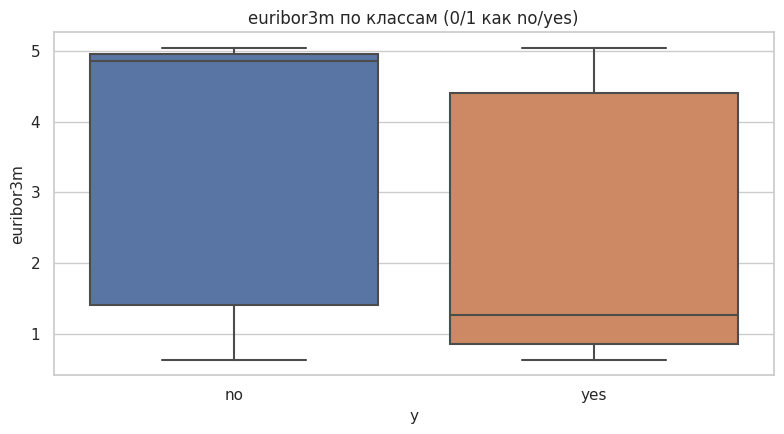

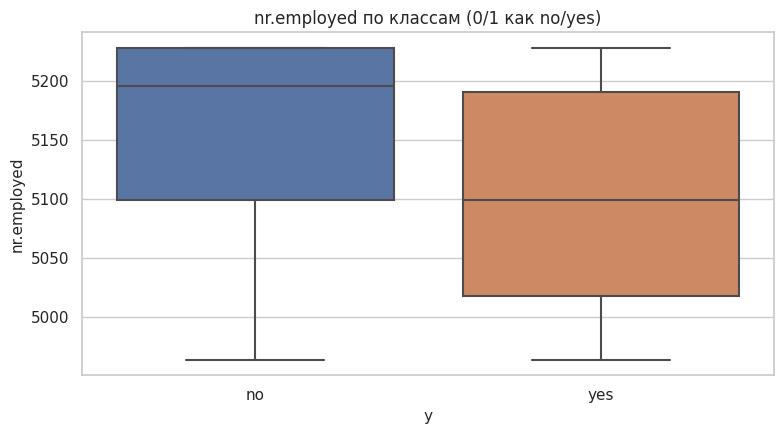

In [29]:
for col in num_cols:
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="y", y=col, ax=ax)
    ax.set(title=f"{col} по классам (0/1 как no/yes)", xlabel="y", ylabel=col)
    plt.tight_layout(); plt.show()

## числовые признаки по классам (boxplot-анализ)

- **age** - возраст клиентов, согласившихся на вклад, чуть ниже, чем у отказавшихся. Медиана для `yes` около 35 лет, для `no` — ближе к 40  
  Можно предположить, что молодые клиенты чаще соглашаются на предложение банка.  
  Выбросы (70–90 лет) единичные, не требуют удаления

- **duration** - заметное различие: при успешных кампаниях (`yes`) звонки в среднем длятся дольше, чем при отказах, но это пост-фактум признак, поэтому в моделях его использовать нельзя, приведёт к утечке данных

- **previous** - у клиентов с положительным откликом медиана выше, то есть предыдущие контакты повышают шанс согласия.  
  Возможно, полезно добавить бинарную фичу `had_prev_contact` и рассматривать взаимодействие с переменной `poutcome`.

- **emp.var.rate** - более низкие значения (хуже макроэкономические условия) чаще связаны с `yes`.  
  Гипотеза: в периоды экономического спада клиенты охотнее откликаются на предложения о сбережениях.

- **euribor3m, cons.price.idx, cons.conf.idx, nr.employed** - наблюдается смещение распределений между классами:  
  отклик (`yes`) чаще в периоды низких ставок и низкой занятости, что также согласуется с экономической логикой.


## Распределения категориальных признаков

In [32]:
cat_cols_wo_y = [c for c in cat_cols if c != "y"]

In [33]:
for col in cat_cols_wo_y[:8]:
    vc = df[col].value_counts().head(12)
    fig = px.bar(x=vc.index, y=vc.values, title=f"{col}: топ категорий")
    fig.update_layout(xaxis_title=col, yaxis_title="count")
    fig.show()

## Анализ категориальных признаков

- **job** - большинство клиентов работают в административной сфере, на производстве и в технических профессиях.  
 Такие группы могут составлять основную аудиторию маркетинговых кампаний.  
  Редкие категории (`student`, `housemaid`, `unemployed`) имеют малую представленность, но могут показывать иную динамику отклика.

- **marital** - преобладают женатые/замужние клиенты (60%), за ними идут одинокие (25%) и разведённые (10%).  
  Семейное положение может отражать финансовую стабильность и влиять на склонность к сбережениям

- **education** - наибольшая доля клиентов имеет высшее или среднее образование.  
  Это может коррелировать с уровнем дохода и финансовой осведомлённостью

- **housing** - около половины клиентов имеют ипотеку.Возможный интерес к депозитам как форме накопления.

- **loan** - большинство клиентов не имеют персональных кредитов.  
  Наличие кредита может снижать вероятность отклика на предложение о депозите, так как финансы уже направлены на закрытие долга

- **month** - активность кампаний сосредоточена в мае, июле и августе.  
  Можно предположить, что весенне-летний период был основным этапом набора вкладов

In [34]:
for col in cat_cols_wo_y[:6]:
    fig = px.histogram(df, x=col, color="y", barmode="group",
                       title=f"{col} по классам y")
    fig.update_layout(xaxis_title=col, yaxis_title="count", legend_title="y")
    fig.show()

 **Вывод:**  
По всем основным категориальным признакам наблюдаются закономерные различия между классами.  

Визуально, наиболее значимыфми фичамидля модели выглядят `job`, `education`, `loan` и `marital`  

# 5 Выбор метрики

Основная метрика: **f1-score**  

Обоснование: классы несбалансированы. f1 учитывает precision и recall(
(Вспомогательные: **roc auc**, **recall** по классу `yes` (не упустить потенциальных клиентов))

# Общий вывод для HW 1

## Постановка задачи и выбор метрики

**Цель проекта:**  
Построить модель, которая будет прогнозировать, согласится ли клиент банка на открытие депозита (`y = yes` / `no`)  
на основе социально-демографических, финансовых и макроэкономических характеристик

**Тип задачи:**  
Классификация (бинарная)

---

### Бизнес-задача
Для банка важно оптимизировать маркетинговые кампании: понимать, какие клиенты с большей вероятностью откликнутся на предложение, чтобы сократить затраты на обзвон и повысить конверсию.

Таким образом, модель должна:
- выявлять наиболее перспективных клиентов,
- минимизировать количество бесполезных контактов ("ложных срабатываний"),
- помочь в таргетировании при последующих кампаниях.

---

### Техническая постановка задачи
На вход модели подаются признаки клиента и текущего контекста (job, education, loan, month, duration и др.),  
на выходе — вероятность положительного отклика (`P(y = yes)`)

---

### Выбор метрик
Так как классы целевой переменной несбалансированы (примерно 11% "yes"), важно использовать метрики, учитывающие этот дисбаланс:

- **F1-score** - основная метрика, отражающая баланс между полнотой и точностью
- **ROC-AUC** - дополнительная метрика, показывающая качество ранжирования вероятностей
- **Precision / Recall** - полезны для оценки ошибок 1-го и 2-го рода (например, сколько “yes” - клиентов модель не заметила).

---

### Критерий успеха
- Достигнут F1-score ≥ 0.60 (больше веротности угадывания, базовый ориентир для начальной модели)  
- Модель должна демонстрировать устойчивое поведение на кросс-валидации и не переобучаться
- Дополнительно: адекватная интерпретация признаков и их влияние на вероятность отклика


#-------- 
# HW 2

In [39]:
# таргет в 0/1
y = (df['y'] == 'yes').astype(int)

In [40]:
# списки признаков (ещё раз для удобства)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [41]:
if 'y' in cat_cols:
    cat_cols.remove('y')
if 'duration' in num_cols:
    num_cols.remove('duration')

In [42]:
X = df[num_cols + cat_cols]

In [46]:
print('n_samples:', X.shape[0], 'n_features:', X.shape[1])

n_samples: 41188 n_features: 19


In [45]:
print('numeric:', num_cols)

numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [44]:
print('categorical:', cat_cols)

categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [48]:
##train/test split со стратификацией

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

print('train:', X_train.shape, 'test:', X_test.shape)
print('class balance train:', y_train.mean().round(4), 'test:', y_test.mean().round(4))


train: (32950, 19) test: (8238, 19)
class balance train: 0.1127 test: 0.1126


Баланс классов:
train = 0.1127, test = 0.1126 

Сохранена стратификация (это значит, что):

положительный класс (yes) занимает 11,2% и в train, и в test

### DummyClassifier (constant baseline) - измерим качество "угадайки", чтобы знать, от чего отталкиваться

In [49]:
dummy = DummyClassifier(strategy='most_frequent', random_state=seed)
dummy.fit(X_train, y_train)


DummyClassifier(random_state=42, strategy='most_frequent')

In [50]:
y_pred_dummy = dummy.predict(X_test)
# для roc_auc создаём константную "вероятность"
y_proba_dummy = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

In [52]:
def evaluate_clf(y_true, y_pred, y_proba=None, title=''):
    print(f'=== {title} ===')
    print('f1:', f1_score(y_true, y_pred).round(4))
    print('precision:', precision_score(y_true, y_pred, zero_division=0).round(4))
    print('recall:', recall_score(y_true, y_pred).round(4))
    if y_proba is not None:
        print('roc_auc:', roc_auc_score(y_true, y_proba).round(4))
    print('confusion_matrix:\n', confusion_matrix(y_true, y_pred))
    print()

In [53]:
evaluate_clf(y_test, y_pred_dummy, y_proba_dummy, title='dummy (most_frequent)')

=== dummy (most_frequent) ===
f1: 0.0
precision: 0.0
recall: 0.0
roc_auc: 0.5
confusion_matrix:
 [[7310    0]
 [ 928    0]]



### Константный бейзлайн

В качестве нулевой точки выбрана модель `DummyClassifier(strategy='most_frequent')`,  
которая всегда предсказывает наиболее частый класс — «no».

Результаты на тестовой выборке:
- F1 = 0.0
- Precision = 0.0
- Recall = 0.0
- ROC-AUC = 0.5

Это соответствует случайному угадыванию и служит минимальным уровнем качества,  
от которого будем отталкиваться 

# Модель №1 Logistic regression (ohe + scaling)

### Почему выбран One-Hot Encoding для логистической регрессии

Логистическая регрессия - это линейная модель и для неё важно, чтобы:
- признаки имели числовую природу (без порядковой интерпретации категорий),
- вклад каждой категории можно было оценить независимо

Поэтому для категориальных признаков выбран метод One-Hot Encoding (OHE):
- каждая категория превращается в отдельный бинарный признак (0/1),
- модель может назначать отдельный вес каждой категории,
- отсутствует ложный "порядок" между категориями, как в Ordinal Encoding.

Также добавлены:
- handle_unknown='ignore', чтобы модель корректно обрабатывала новые значения на тесте,
- SimpleImputer(strategy='most_frequent'), чтобы заполнить пропуски наиболее частым значением.

Для числовых признаков применено масштабирование (StandardScaler),  
поскольку логистическая регрессия чувствительна к масштабу данных:  признаки с большими значениями могут доминировать при обучении


In [55]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [56]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

In [57]:
preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

In [58]:
logreg = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, C=1.0, penalty='l2', random_state=seed))
])

In [59]:
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]

In [60]:
evaluate_clf(y_test, y_pred_lr, y_proba_lr, title='logistic regression (baseline)')

=== logistic regression (baseline) ===
f1: 0.335
precision: 0.6926
recall: 0.2209
roc_auc: 0.8007
confusion_matrix:
 [[7219   91]
 [ 723  205]]

